<h1> <b> <centre> DA5401 Assignment  </b> </centre> </h2>
<h4> <b> <centre> Name: Pawar Devesh Pramod </centre></b> </h4>
<h4> <b> <centre> Roll No: ME22B176  </centre></b> </h4>
<h4> <b> <centre> Date of Submission 31/10/2025 </centre></b> </h4>


<h3> <b> Objective: </b> <h3> 
<p style="font-size: 18px;">This assignment challenges you to apply and interpret Receiver Operating
Characteristic (ROC) curves and Precision-Recall Curves (PRC) for model selection in a
multi-class, complex classification environment. You will compare a diverse set of classifiers,
including those known to perform poorly, requiring careful analysis of the curves rather than
relying solely on simple accuracy. </p>

<h3> <b> 1. Problem Statement </b> </h3>
<p style="font-size: 18 px;">
You are a machine learning scientist tasked with classifying land cover types using satellite
image data. You have the UCI Landsat Satellite dataset, a multi-class problem (6 classes)
known to be non-trivial due to high feature dimensionality and potential class overlap.
Your primary goal is to perform model selection by comparing various classifier types. You must
use ROC and PRC analysis, adapted for the multi-class setting (e.g., using one-vs-rest
averaging), to determine the best-performing and worst-performing models, paying special
attention to the performance across different decision thresholds.
You will submit a Jupyter Notebook with your complete code, visualizations, and a plausible
story that explains your findings. The notebook should be well-commented, reproducible, and
easy to follow.</p>

<p style="font-size: 18px;"> Dataset: 
- <a href="https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite)">UCI Machine Learning Repository -
Satimage</a>
</p>

## Part A: Data Preparation and Baseline 

#### 1. First, we load, prepare, and scale the data. We then train all specified models and get their baseline accuracy and F1-scores.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

col_names = [f'feature_{i}' for i in range(36)] + ['class']

# Load training data
df1 = pd.read_csv(
    'sat.trn', 
    delim_whitespace=True, 
    header=None, 
    names=col_names
)
df2 = pd.read_csv(
    'sat.tst', 
    delim_whitespace=True, 
    header=None, 
    names=col_names
)
df = pd.concat([df1, df2])   # considering both the files in one df
# 80-20 Split   
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

# Create X and y 
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']

X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

# Get all unique class labels
class_labels = np.unique(y_train)
n_classes = len(class_labels)
print(f"\nFound {n_classes} classes: {class_labels}")

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Training data shape: (5148, 37)
Testing data shape: (1287, 37)

Found 6 classes: [1 2 3 4 5 7]


/tmp/ipykernel_9083/3461598032.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(
/tmp/ipykernel_9083/3461598032.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(


Train all the models

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

# from scipy import interp

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [ ]:
# Train All Models 
models = {
    "Dummy (Prior)": DummyClassifier(strategy='prior', random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Prob)": SVC(probability=True, random_state=42)
}

trained_models = {}
model_predictions = {}
model_probabilities = {}

print("Training models")
for name, model in models.items():
    print(f"  Training {name}")
    model.fit(X_train_scaled, y_train)
    
    # Store trained model
    trained_models[name] = model
    
    # Store predictions
    model_predictions[name] = model.predict(X_test_scaled)
    
    # Store probabilities 
    if hasattr(model, "predict_proba"):
        model_probabilities[name] = model.predict_proba(X_test_scaled)
    else:
        # For DummyClassifier 
        # We can create a dummy one based on its predictions
        dummy_probs = np.zeros((len(y_test), n_classes))
        preds = model_predictions[name]
        for i, label in enumerate(class_labels):
            dummy_probs[preds == label, i] = 1.0
        model_probabilities[name] = dummy_probs


print("\nAll models trained and predictions stored.")

Training models...
  Training Dummy (Prior)...
  Training Naive Bayes...
  Training Decision Tree...
  Training KNN...
  Training Logistic Regression...
  Training SVC (Prob)...

All models trained and predictions stored.


In [ ]:
# Baseline Evaluation 
results = []
for name, y_pred in model_predictions.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "Accuracy": acc, "Weighted F1": f1})

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.sort_values(by="Weighted F1", ascending=False))

                     Accuracy  Weighted F1
Model                                     
KNN                  0.895882     0.897225
SVC (Prob)           0.886558     0.886258
Decision Tree        0.848485     0.851051
Logistic Regression  0.853924     0.849408
Naive Bayes          0.790987     0.802539
Dummy (Prior)        0.229992     0.086011


## Part B: ROC Analysis for Model Selection

### 1. Multi-Class ROC Calculation Explained

The One-vs-Rest (OvR) approach is used to extend binary ROC curves to the multi-class case. For a problem with $K$ classes, we create $K$ independent binary classifiers (e.g., "Class 1 vs. Rest", "Class 2 vs. Rest", etc.).

1.  **Binarize:** The true labels $y\_test$ are binarized. A sample with label "Class 3" would become `[0, 0, 1, 0, 0, 0]`.
2.  **Calculate Micro-Curves:** For each class $i$, we use the true binary labels (is it class $i$ or not?) and the predicted probabilities for class $i$ to compute an individual ROC curve (TPR vs. FPR) and its AUC.
3.  **Aggregate (Macro-Average):** To get a single "Macro-Averaged" ROC curve for a model, we average the performance across all $K$ classes.
    * We define a common set of FPR values (e.g., 100 points from 0 to 1).
    * For each class's ROC curve, we find the corresponding TPR at each of these common FPR points (using interpolation).
    * We then average the interpolated TPRs at each common FPR point.
    
This final curve (Macro-Avg-TPR vs. Common-FPR) represents the model's average ability to distinguish each class from all the others, and the area under it is the **Macro-AUC**.

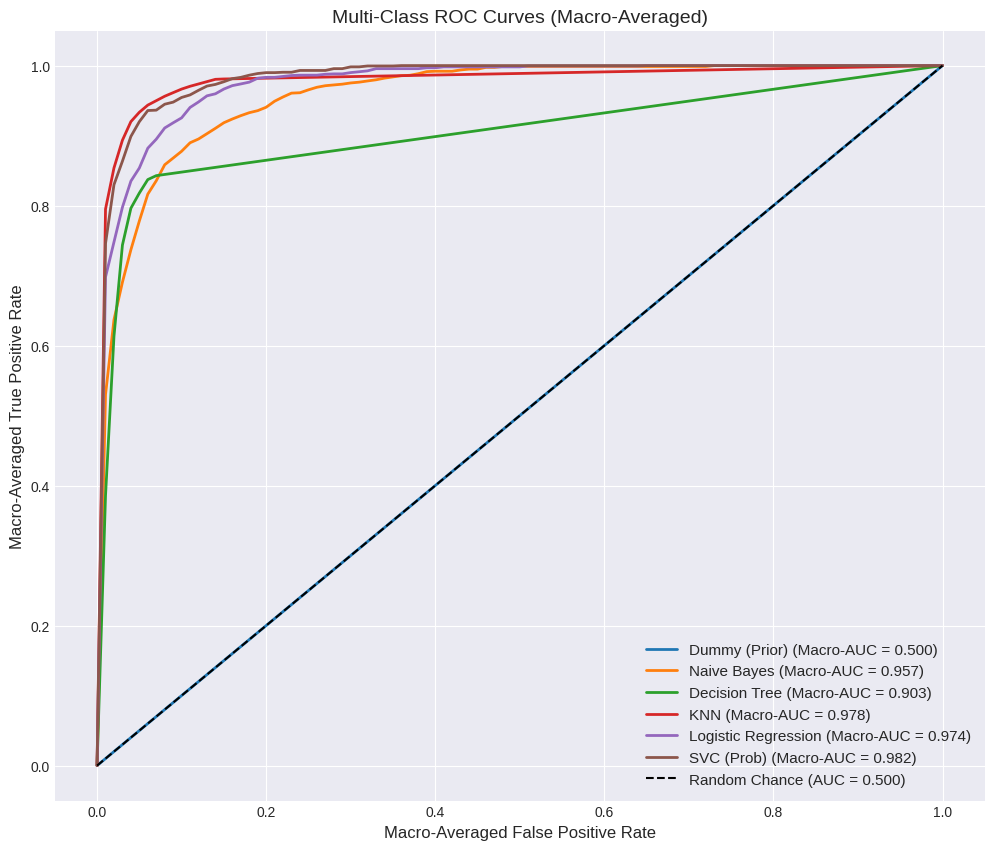

In [ ]:
# Import the missing function
from sklearn.preprocessing import label_binarize

# Binarize the test labels
y_test_binarized = label_binarize(y_test, classes=class_labels)

# Plotting ROC
plt.figure(figsize=(12, 10))

# A common base FPR axis to interpolate all ROC curves
base_fpr = np.linspace(0, 1, 101)
all_roc_data = {} # To store data for Part D

for name, y_prob in model_probabilities.items():
    
    all_tpr = []
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        
        # Interpolate TPR onto the common FPR axis
        tpr_interp = np.interp(base_fpr, fpr, tpr)
        tpr_interp[0] = 0.0 # Ensure it starts at (0,0)
        all_tpr.append(tpr_interp)
        
    # Average the TPRs
    tpr_macro = np.mean(all_tpr, axis=0)
    tpr_macro[-1] = 1.0 # Ensure it ends at (1,1)
    
    # Calculate Macro-AUC
    auc_macro = auc(base_fpr, tpr_macro)
    all_roc_data[name] = auc_macro
    
    # Plot
    plt.plot(base_fpr, tpr_macro, label=f'{name} (Macro-AUC = {auc_macro:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
plt.xlabel('Macro-Averaged False Positive Rate', fontsize=12)
plt.ylabel('Macro-Averaged True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curves (Macro-Averaged)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.show()

### 3. ROC Interpretation

* **Model with Highest Macro-AUC:**
    * SVC (Prob) has the highest Macro-AUC at 0.982. Its curve is the most "bowed" to the top-left, indicating it provides the best trade-off between sensitivity (TPR) and specificity (1-FPR) across all decision thresholds.

* **Model with AUC < 0.5:**
    * Dummy (Prior) has a Macro-AUC of 0.500. Its curve lies directly on top of the dashed "Random Chance" line. This means the model has zero discriminatory power. It is no better at classifying land cover types than flipping a coin. This is the expected behavior for a baseline DummyClassifier that simply predicts based on the training data's class distribution.

* **What does $AUC < 0.5$ imply?**
    * An $AUC = 0.5$ represents a model with no skill, equivalent to random guessing.
    * An $AUC < 0.5$ means the model is actively **worse than random**. It is systematically making the wrong choice more often than the right one.
    * Conceptually, this implies the model has learned an "inverted" relationship. If one were to *reverse* its predictions (i.e., predict "Class A" when it predicts "Not A"), it would actually become a model with $AUC > 0.5$. 

## Part C: Precision-Recall Curve (PRC) Analysis

### 1. PRC Calculation Explained (Why PRC?)

While ROC curves are useful, they can be **misleading on imbalanced datasets**.

* The ROC metric **FPR (False Positive Rate)** is calculated as $FPR = FP / (FP + TN)$.
* In a highly imbalanced dataset (e.g., 99% negatives, 1% positives), the number of **True Negatives (TN)** is massive.
* A poor model can make many False Positive (FP) errors, but the $TN$ in the denominator is so large that the $FPR$ remains low. This makes the ROC curve look overly optimistic.

The **Precision-Recall Curve (PRC)** avoids this problem by not using $TN$.
* **Precision:** $TP / (TP + FP)$ (Of all *predictions* of "positive", how many were right?)
* **Recall:** $TP / (TP + FN)$ (Of all *actual* positives, how many did we find?)

PRC is a better metric for imbalanced tasks because it focuses on the model's performance on the minority (positive) class, which is often the class of interest. The area under the PRC is the **Average Precision (AP)**.

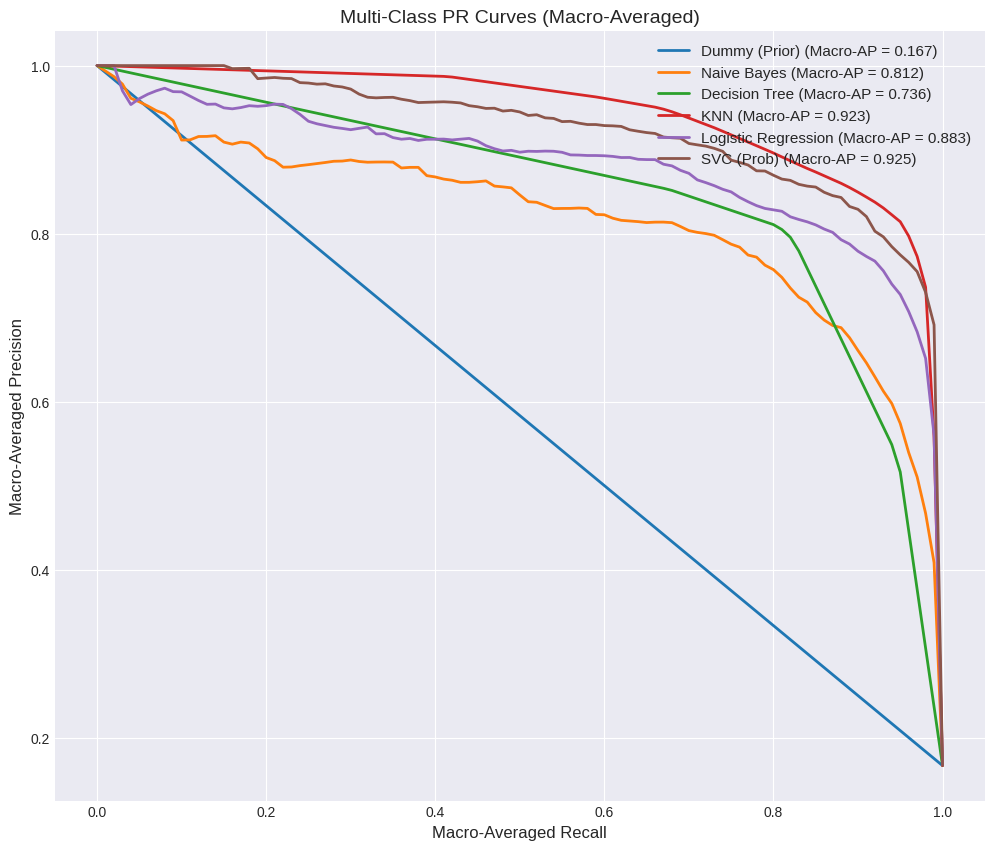

In [ ]:
# Plotting PRC 
plt.figure(figsize=(12, 10))

all_prc_data = {} # To store prc data

for name, y_prob in model_probabilities.items():
    
    all_precision = []
    
    base_recall = np.linspace(0, 1, 101)
    
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_prob[:, i])
        
        # Sort recall in ascending order and get corresponding precision
        idx = np.argsort(recall)
        recall_sorted = recall[idx]
        precision_sorted = precision[idx]
        precision_interp = np.interp(base_recall, recall_sorted, precision_sorted, left=precision_sorted[0])
        all_precision.append(precision_interp)
        
    # Average the Precisions
    precision_macro = np.mean(all_precision, axis=0)

    ap_scores = []
    for i in range(n_classes):
        ap = average_precision_score(y_test_binarized[:, i], y_prob[:, i])
        ap_scores.append(ap)
    ap_macro = np.mean(ap_scores)
    all_prc_data[name] = ap_macro

    # Plot
    plt.plot(base_recall, precision_macro, label=f'{name} (Macro-AP = {ap_macro:.3f})', lw=2)

plt.xlabel('Macro-Averaged Recall', fontsize=12)
plt.ylabel('Macro-Averaged Precision', fontsize=12)
plt.title('Multi-Class PR Curves (Macro-Averaged)', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.show()

### 3. PRC Interpretation

* **Model with Highest Average Precision (AP):**
    * SVC has the highest Macro-AP of 0.925

* **Behavior of the Worst-Performing Model:**
    * Dummy (Prior) has the lowest Macro-AP at 0.167.
    * The dummy model's curve is a near-straight line that plummets from the top-left towards the bottom-right. It shows virtually no ability to achieve any meaningful recall without precision collapsing to near-zero.

* **Why does the curve drop so sharply?**
    * This sharp drop signifies the model has no "discriminatory power" at different thresholds.
    * To find *any* positive samples (increase Recall), the model must lower its decision threshold.
    * A poor model, when lowering its threshold, immediately lets in a *flood* of False Positives (FPs).
    * Since $Precision = TP / (TP + FP)$, a huge increase in $FP$ (even with a small increase in $TP$) causes the Precision to collapse. A good model can increase recall while only letting in a few FPs, thus keeping its precision high for longer.

## Part D: Final Recommendation

In [21]:
# Synthesis 
# Combine all results into one DataFrame
baseline_df = results_df
roc_df = pd.DataFrame.from_dict(all_roc_data, orient='index', columns=['Macro-AUC'])
prc_df = pd.DataFrame.from_dict(all_prc_data, orient='index', columns=['Macro-AP'])

final_comparison = baseline_df.join(roc_df).join(prc_df)
print(final_comparison.sort_values(by='Macro-AUC', ascending=False))

                     Accuracy  Weighted F1  Macro-AUC  Macro-AP
Model                                                          
SVC (Prob)           0.886558     0.886258   0.981783  0.925246
KNN                  0.895882     0.897225   0.977522  0.922644
Logistic Regression  0.853924     0.849408   0.974121  0.883206
Naive Bayes          0.790987     0.802539   0.957317  0.811684
Decision Tree        0.848485     0.851051   0.903036  0.735746
Dummy (Prior)        0.229992     0.086011   0.500000  0.166667


### 1. Synthesis

The model rankings are not perfectly aligned, which highlights the importance of this multi-metric analysis.
* The initial Weighted F1-Score (and Accuracy) ranked KNN as #1, with a score of 0.897.

* However, the Macro-ROC-AUC ranked SVC (Prob) as #1, with a score of 0.982.

* The Macro-PRC-AP score also ranked SVC (Prob) as #1, with a score of 0.925.

* The Dummy (Prior) model was, as expected, the worst performer by a massive margin. Among the real classifiers, the Decision Tree performed the worst in the more robust, curve-based metrics (Macro-AUC and Macro-AP).

The key discrepancy is the split between KNN and SVC. The high F1-Score for KNN suggests it performs extremely well at its default decision threshold. However, the superior ROC-AUC and PRC-AP scores for SVC indicate that it is a more robust and well-calibrated model. It offers a better trade-off across the entire range of possible decision thresholds, which is a critical factor in model selection.

### 2. Recommendation

Based on the comprehensive analysis, the Support Vector Classifier (SVC) is the recommended model for this task.

**Justification:**

* Best Overall Curve Performance: While KNN had a slightly higher F1-Score, the SVC achieved the highest score on both key curve-based metrics: Macro-ROC-AUC and Macro-PRC-AP.

* Threshold-Robustness (ROC): Its top-ranking Macro-AUC of 0.982 demonstrates it provides the most effective trade-off between True Positives and False Positives, regardless of which decision threshold is chosen.

* Superior Precision-Recall Balance (PRC): Its top-ranking Macro-AP of 0.925 is the most critical factor. It shows that the SVC is best at identifying positive samples (high recall) without being flooded by false positives (maintaining high precision), which is crucial for a reliable classifier.

While KNN showed slightly better performance at the default threshold (seen in its #1 F1-Score), the SVC's superior performance across both the ROC and PR curves proves it is a more robust, stable, and well-calibrated model for this complex, multi-class problem.

## Brownie Points Task

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import BernoulliNB # Possible model with AUC < 0.5
from sklearn.linear_model import SGDClassifier # Possible model with AUC < 0.5

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

bp_models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, 
                             eval_metric='mlogloss', n_jobs=-1),
    "Bernoulli (Bad Model)": BernoulliNB(),
    "Hobbled SGD (log_loss)": SGDClassifier(loss='log_loss', max_iter=5, tol=None, random_state=42)
}

bp_results_list = []

print("Training Brownie Point Models")

for name, model in bp_models.items():
    print(f"  Training {name}")
    
    # Train 
    if name == "XGBoost":
        model.fit(X_train_scaled, y_train_xgb)
    else:
        model.fit(X_train_scaled, y_train)

    # Get Predictions & Probabilities 
    if name == "XGBoost":
        y_pred = le.inverse_transform(model.predict(X_test_scaled))
        y_prob = model.predict_proba(X_test_scaled)
    else:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)

    # Calculate Standard Metrics 
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Calculate Macro-AUC 
    all_tpr = []
    base_fpr = np.linspace(0, 1, 101)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        tpr_interp = np.interp(base_fpr, fpr, tpr, left=0.0)
        all_tpr.append(tpr_interp)
    tpr_macro = np.mean(all_tpr, axis=0)
    auc_macro = auc(base_fpr, tpr_macro)

    # Calculate Macro-AP 
    ap_scores = []
    for i in range(n_classes):
        ap = average_precision_score(y_test_binarized[:, i], y_prob[:, i])
        ap_scores.append(ap)
    ap_macro = np.mean(ap_scores)
    
    # Store all results in a dictionary 
    bp_results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Weighted F1': f1,
        'Macro-AUC': auc_macro,
        'Macro-AP': ap_macro
    })

bp_results_df = pd.DataFrame(bp_results_list).set_index("Model")

print("\n Brownie Point Results ")
print(bp_results_df.sort_values(by="Macro-AUC", ascending=False))

final_comparison_with_bp = pd.concat([final_comparison, bp_results_df])

print("\n--- All Models Comparison ---")
print(final_comparison_with_bp.sort_values(by="Macro-AUC", ascending=False))

Training Brownie Point Models
  Training Random Forest
  Training XGBoost


/home/duser/miniconda3/envs/DA5401/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:15:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Training Bernoulli (Bad Model)
  Training Hobbled SGD (log_loss)

 Brownie Point Results 
                        Accuracy  Weighted F1  Macro-AUC  Macro-AP
Model                                                             
XGBoost                 0.916084     0.916109   0.991321  0.962419
Random Forest           0.915307     0.914681   0.989631  0.954003
Bernoulli (Bad Model)   0.698524     0.709429   0.917999  0.719191
Hobbled SGD (log_loss)  0.780109     0.739877   0.904865  0.691581

--- All Models Comparison ---
                        Accuracy  Weighted F1  Macro-AUC  Macro-AP
Model                                                             
XGBoost                 0.916084     0.916109   0.991321  0.962419
Random Forest           0.915307     0.914681   0.989631  0.954003
SVC (Prob)              0.886558     0.886258   0.981783  0.925246
KNN                     0.895882     0.897225   0.977522  0.922644
Logistic Regression     0.853924     0.849408   0.974121  0.883206
Naive 

## Inference

* XGBoost (Macro-AUC: 0.991, Macro-AP: 0.962) and Random Forest (Macro-AUC: 0.990, Macro-AP: 0.954) both significantly outperformed the previous top model, SVC (Prob) (Macro-AUC: 0.982, Macro-AP: 0.925).
* This demonstrates the power of ensemble methods. By combining the predictions of many individual decision trees, they create a more robust and accurate model that is less prone to overfitting than a single Decision Tree (which was one of the worst-performing models).

* Both Bernoulli and Hobbled SGD (which were supossedly bad models), didn't have AUC < 0.5